In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("/content/final_internship_data.csv")
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6.0,0.0,2009.0,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1.0,1.0,2010.0,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8.0,3.0,2011.0,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4.0,5.0,2012.0,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3.0,1.0,2010.0,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [ ]:
#Quick Structural Check
print(df.shape)
print(df.info())

(27646, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27646 entries, 0 to 27645
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User ID            27646 non-null  object 
 1   User Name          27646 non-null  object 
 2   Driver Name        27646 non-null  object 
 3   Car Condition      27646 non-null  object 
 4   Weather            27646 non-null  object 
 5   Traffic Condition  27646 non-null  object 
 6   key                27646 non-null  object 
 7   fare_amount        27646 non-null  float64
 8   pickup_datetime    27646 non-null  object 
 9   pickup_longitude   27646 non-null  float64
 10  pickup_latitude    27646 non-null  float64
 11  dropoff_longitude  27645 non-null  float64
 12  dropoff_latitude   27645 non-null  float64
 13  passenger_count    27645 non-null  float64
 14  hour               27645 non-null  float64
 15  day                27645 non-null  float64
 16  month     

Q1) What does the overall fare distribution look like? Are there outliers?

fare_amount: Numerical

Suitable plot: Histogram + Boxplot

Why: Histogram shows the shape/skew of a single numeric variable; boxplot complements it by clearly flagging outliers and spread that a histogram can hide.


Interpretation: Most rides have a low, similar fare  the distribution is Left-skewed with a long tail of expensive trips. These look like real premium/long-distance rides rather than data errors, so they'll need to be handled carefully in modeling instead of just dropped.


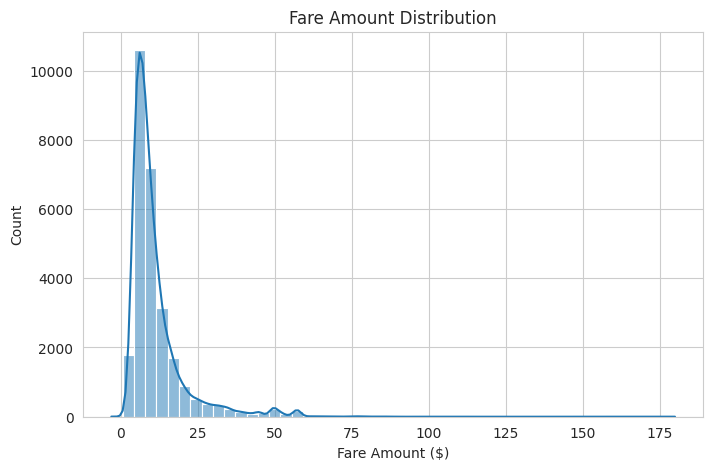

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title('Fare Amount Distribution')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Count')
plt.show()

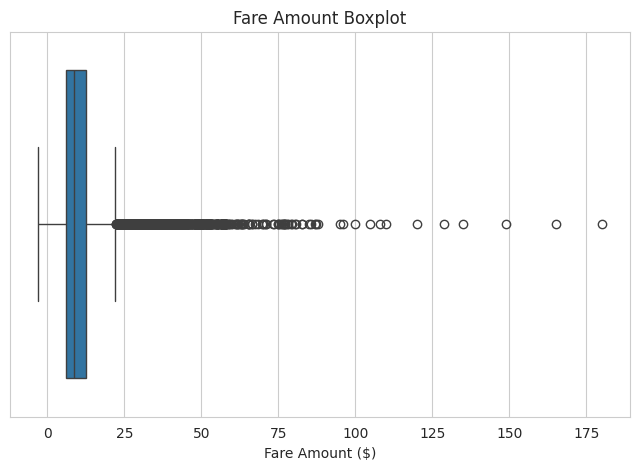

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['fare_amount'])
plt.title('Fare Amount Boxplot')
plt.xlabel('Fare Amount ($)')
plt.show()

Q2) What does the trip distance distribution look like? Are there outliers?

distance: Numerical

Suitable plot: Histogram + Boxplot

Why: Same logic as fare ,histogram shows shape/skew, boxplot flags spread and outliers.

Interpretation: The typical trip is a short 1–4 km hop across the city, but the raw data contains physically impossible distances some negative some more then 8000 clear GPS/data errors that will need cleaning before Task 2.

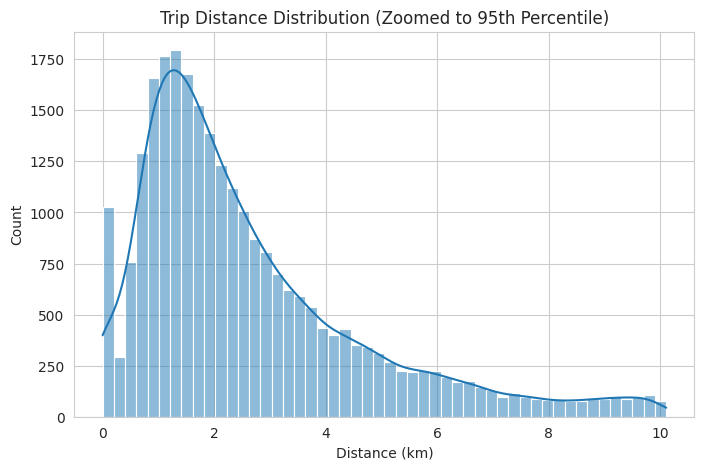

In [ ]:
plt.figure(figsize=(8, 5))
cap = df['distance'].quantile(0.95)
sns.histplot(df[df['distance'] <= cap]['distance'], bins=50, kde=True)
plt.title('Trip Distance Distribution (Zoomed to 95th Percentile)')
plt.xlabel('Distance (km)')
plt.ylabel('Count')
plt.show()

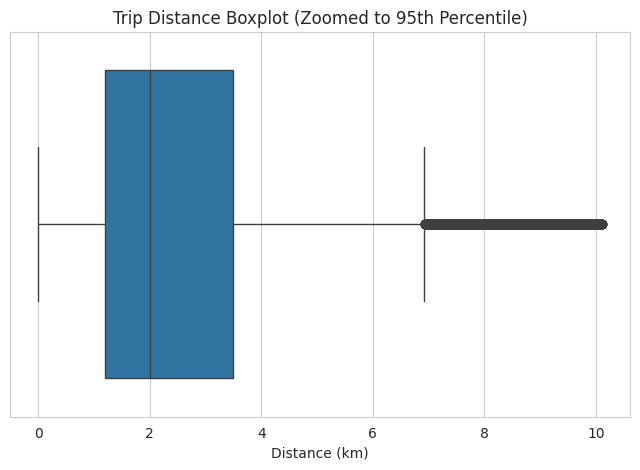

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df[df['distance'] <= cap]['distance'])
plt.title('Trip Distance Boxplot (Zoomed to 95th Percentile)')
plt.xlabel('Distance (km)')
plt.show()

In [ ]:
df['distance'].describe()

,distance
count,27645.000000
mean,15.993411
std,324.544114
min,0.000000
25%,1.225922
50%,2.120904
75%,3.874875
max,8667.542104


Q3) Does trip distance correlate with fare, and how strong is that relationship compared to other features?

distance: Numerical, fare_amount: Numerical

Suitable plot: Scatter Plot + Correlation Heatmap

Why: Scatter shows the shape of the relationship (linear? clustered? noisy?) between two numeric variables.
Correlation heatmap lets us compare this relationship's strength against other numeric features at a glance.


Interpretation: Fare rises steadily and almost linearly with distance. Of all numeric features checked, distance has by far the strongest relationship with fare — it's the single most useful predictor for Task 2.

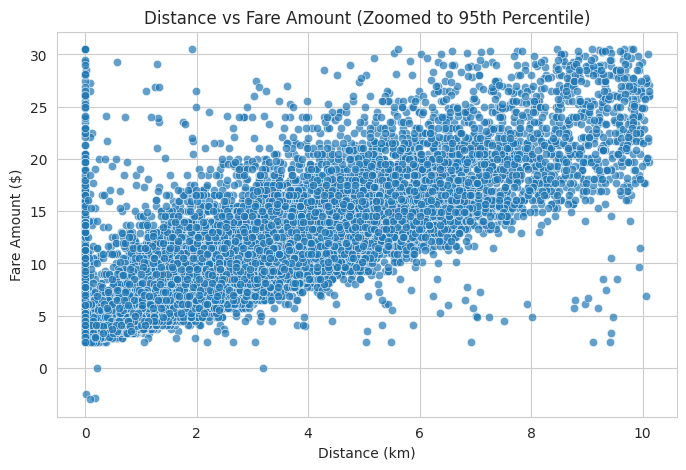

In [ ]:
plt.figure(figsize=(8, 5))
dist_cap = df['distance'].quantile(0.95)
fare_cap = df['fare_amount'].quantile(0.95)

subset = df[(df['distance'] <= dist_cap) & (df['fare_amount'] <= fare_cap)]

sns.scatterplot(x=subset['distance'], y=subset['fare_amount'], alpha=0.7)
plt.title('Distance vs Fare Amount (Zoomed to 95th Percentile)')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.show()

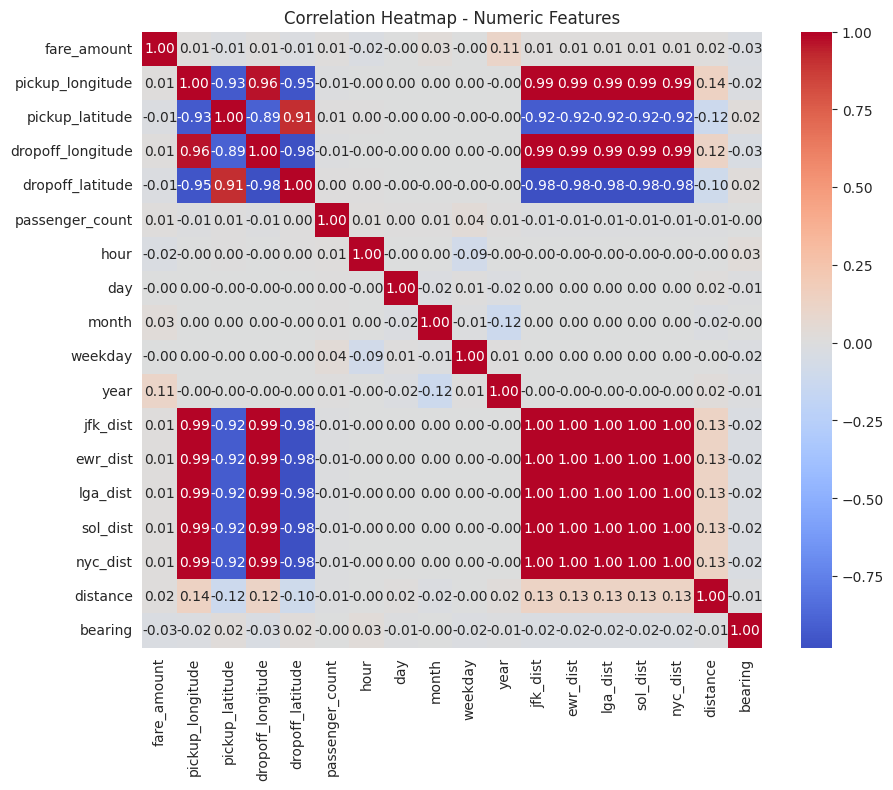

In [ ]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

Q4) Does passenger count affect fare?

passenger_count: Numerical (low-cardinality, treated as categorical)
fare_amount: Numerical

Suitable plot: Boxplot

Why: Passenger count only takes a few discrete values (1-6), so a boxplot per group shows the fare distribution for each passenger count clearly.

Interpretation: Average fare barely changes whether there's 1 passenger or 6 (~$9–12 range). Uber charges per trip, not per person, so this feature adds little predictive value.

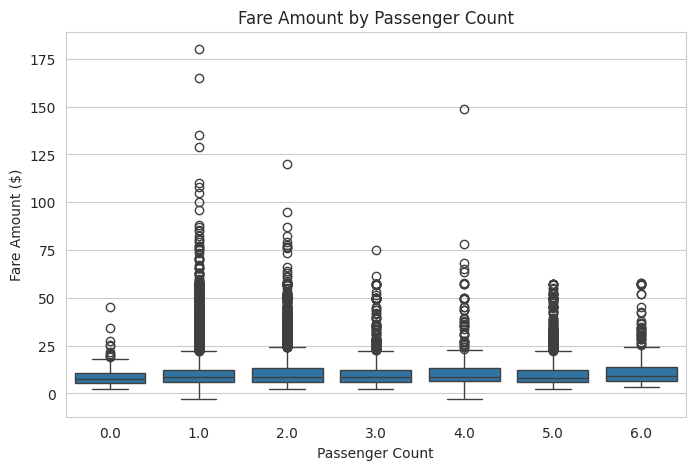

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['passenger_count'], y=df['fare_amount'])
plt.title('Fare Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.show()

Q5) Does car condition influence the fare amount?

Car Condition: Categorical

fare_amount: Numerical

Suitable plot: Boxplot
Why: Compares the fare distribution (median, spread, outliers) across different car condition categories.

Interpretation: Average fare is nearly identical across Bad/Good/Excellent/Very Good cars. Car condition has essentially no effect on fare.

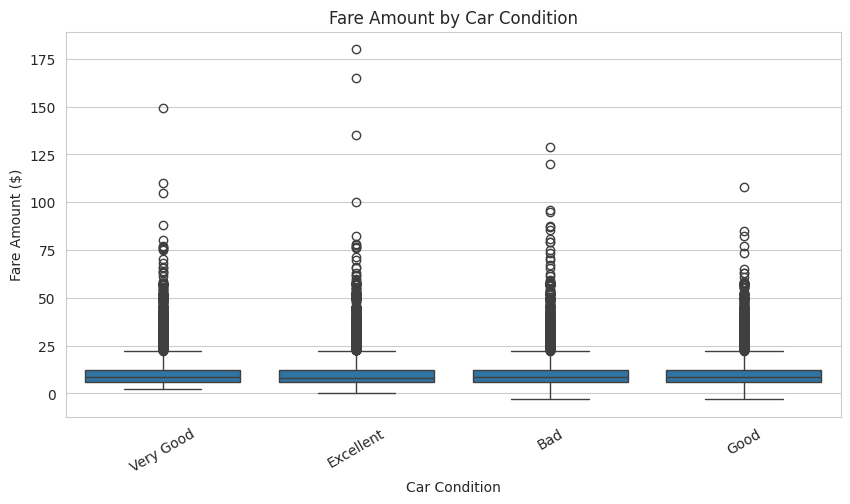

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Car Condition'], y=df['fare_amount'])
plt.title('Fare Amount by Car Condition')
plt.xlabel('Car Condition')
plt.ylabel('Fare Amount ($)')
plt.xticks(rotation=30)
plt.show()

In [ ]:
df.groupby('Car Condition')['fare_amount'].mean()

,fare_amount
Car Condition,
Bad,11.542279
Excellent,11.186538
Good,11.206450
Very Good,11.411158


Q6) Does traffic condition affect the trip fare?

Traffic Condition: Categorical

fare_amount: Numerical

Suitable plot: Bar chart (average fare per category)

Why: Same logic as car condition , bar chart gives a clean comparison of average fare across traffic categories.

Interpretation: Congested, Dense, and Flow traffic show almost the same average fare, even though heavier traffic usually means longer rides. Traffic condition alone isn't a strong fare signal.

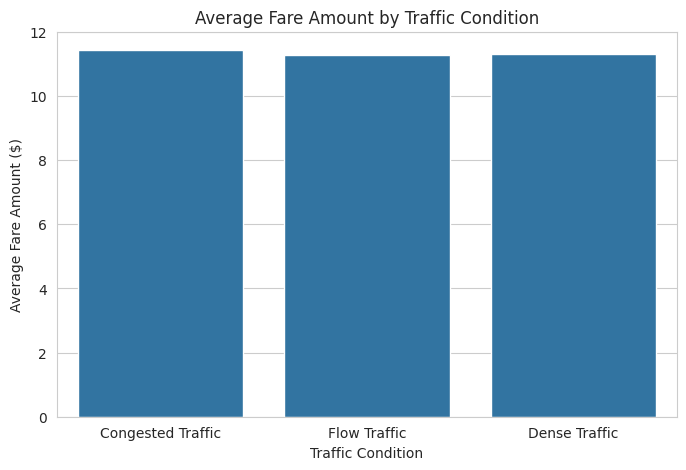

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df['Traffic Condition'], y=df['fare_amount'], estimator='mean' ,errorbar=None)
plt.title('Average Fare Amount by Traffic Condition')
plt.xlabel('Traffic Condition')
plt.ylabel('Average Fare Amount ($)')
plt.show()

In [ ]:
df.groupby('Traffic Condition')['fare_amount'].mean()

,fare_amount
Traffic Condition,
Congested Traffic,11.429490
Dense Traffic,11.313529
Flow Traffic,11.268994


Q7) Does weather condition influence the average trip distance?

Weather: Categorical

distance: Numerical

Suitable plot: Bar chart (average distance per category)

Why: Compares average trip distance across weather conditions , a bar chart gives a clean, direct comparison, consistent with how we handled Car Condition and Traffic Condition.

Interpretation: Average trip distance is roughly flat across weather categories, weather doesn't meaningfully change how far people travel.

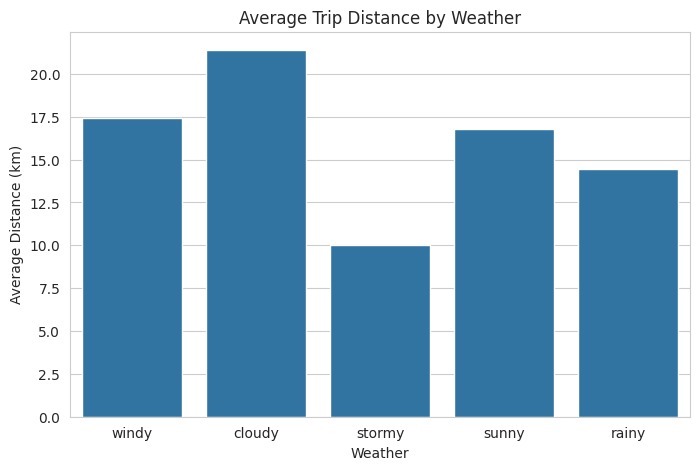

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df['Weather'], y=df['distance'], estimator='mean', errorbar=None)
plt.title('Average Trip Distance by Weather')
plt.xlabel('Weather')
plt.ylabel('Average Distance (km)')
plt.show()

Q8) Are rides that start closer to airports generally more expensive?

jfk_dist (and ewr_dist / lga_dist): Numerical, binned into distance ranges

fare_amount: Numerical

Suitable plot: Bar chart (average fare per distance bin)

Why: jfk_dist contains extreme outliers (max ~30,000 km vs. a real range of ~1-44 km), making a raw scatter plot unreadable. Binning distance into ranges converts it into a clean categorical comparison, letting us directly compare average fare across "closer" vs. "farther" rides without outliers distorting the plot.

Interpretation: Average fare doesn't rise smoothly with JFK distance , it jumps around instead of trending cleanly. That irregularity points to the same data-quality issue as distance: some jfk_dist values likely don't reflect real distances, so this is a cleanup flag for Task 2 rather than a genuine pricing pattern.

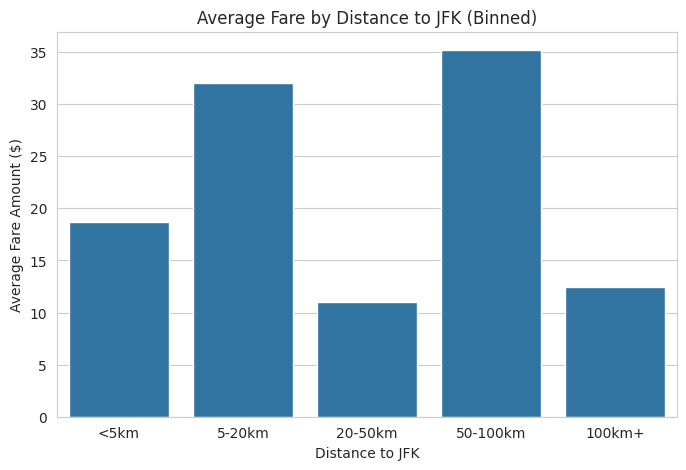

In [ ]:
#JFK dist
plt.figure(figsize=(8, 5))
df['jfk_dist_bin'] = pd.cut(df['jfk_dist'], bins=[0, 5, 20, 50, 100, df['jfk_dist'].max()],
                              labels=['<5km', '5-20km', '20-50km', '50-100km', '100km+'])

sns.barplot(x=df['jfk_dist_bin'], y=df['fare_amount'], estimator='mean', errorbar=None)
plt.title('Average Fare by Distance to JFK (Binned)')
plt.xlabel('Distance to JFK')
plt.ylabel('Average Fare Amount ($)')
plt.show()

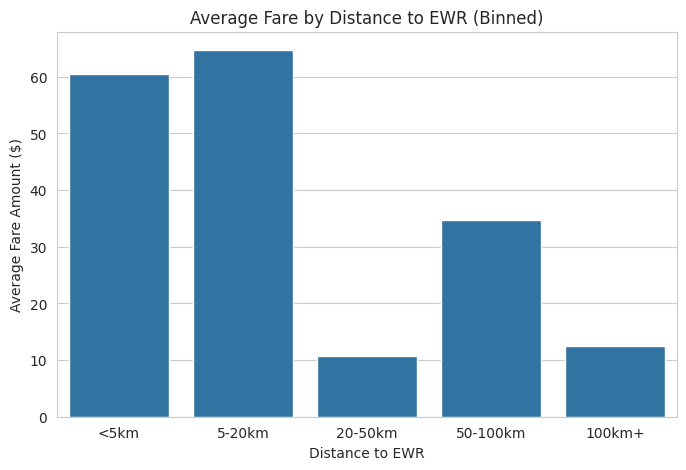

In [ ]:
#EWR dist
plt.figure(figsize=(8, 5))
df['ewr_dist_bin'] = pd.cut(df['ewr_dist'], bins=[0, 5, 20, 50, 100, df['ewr_dist'].max()],
                              labels=['<5km', '5-20km', '20-50km', '50-100km', '100km+'])

sns.barplot(x=df['ewr_dist_bin'], y=df['fare_amount'], estimator='mean', errorbar=None)
plt.title('Average Fare by Distance to EWR (Binned)')
plt.xlabel('Distance to EWR')
plt.ylabel('Average Fare Amount ($)')
plt.show()

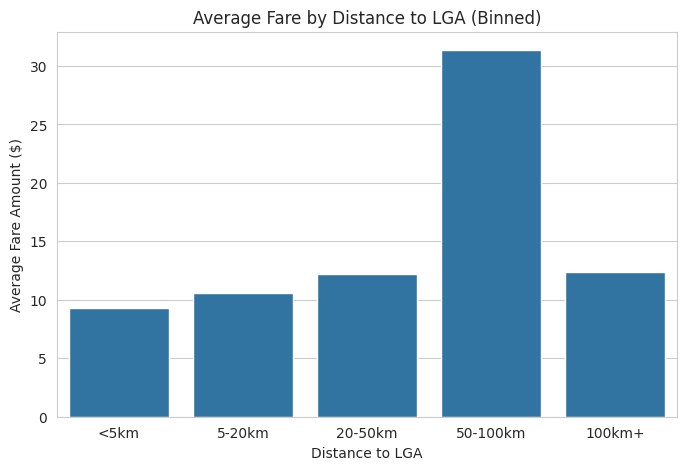

In [ ]:
#LGA dist
plt.figure(figsize=(8, 5))
df['lga_dist_bin'] = pd.cut(df['lga_dist'], bins=[0, 5, 20, 50, 100, df['lga_dist'].max()],
                              labels=['<5km', '5-20km', '20-50km', '50-100km', '100km+'])

sns.barplot(x=df['lga_dist_bin'], y=df['fare_amount'], estimator='mean', errorbar=None)
plt.title('Average Fare by Distance to LGA (Binned)')
plt.xlabel('Distance to LGA')
plt.ylabel('Average Fare Amount ($)')
plt.show()

Q9) At what hour of day are ride requests most frequent?

hour: Numerical (Discrete, 0-23)

Ride Count: Frequency

Suitable plot: Count Plot

Why: Shows the frequency of rides at each hour reveals peak demand hours, independent of fare price.

Interpretation: Rides are quiet overnight, climb steadily through the day, and peak in the evening (around 6–9pm).

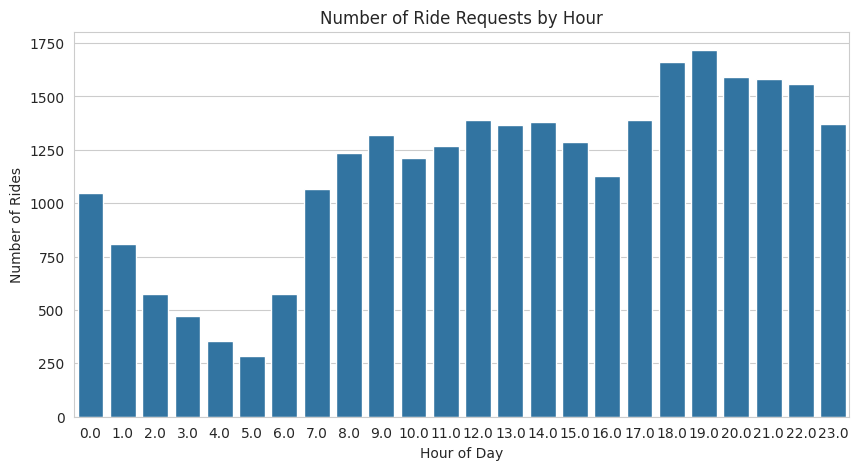

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['hour'])
plt.title('Number of Ride Requests by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.show()

Q10) At what hour of day are fares typically highest?

hour: Numerical (ordered, 0-23)

fare_amount: Numerical

Suitable plot: Line Plot

Why: Hour is an ordered/sequential variable, so a line plot best shows the trend of average fare as the day progresses easier to spot peaks.

Interpretation: Fare stays fairly steady through the day but spikes early morning (4–6am) , likely longer trips like airport runs taken when roads are empty.

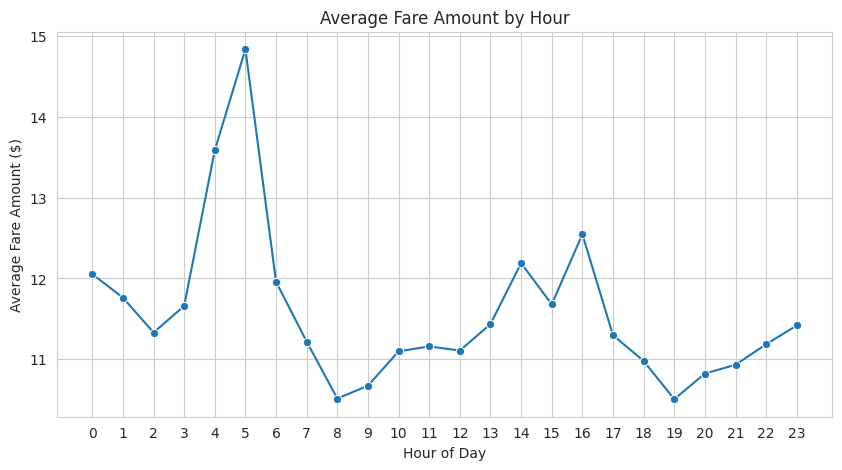

In [ ]:
plt.figure(figsize=(10, 5))
hourly_fare = df.groupby('hour')['fare_amount'].mean()

sns.lineplot(x=hourly_fare.index, y=hourly_fare.values, marker='o')
plt.title('Average Fare Amount by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Amount ($)')
plt.xticks(range(0, 24))
plt.show()

Q11) Does day of week affect ride volume or average fare?

weekday: Categorical/Ordered (0=Monday ... 6=Sunday)

Ride Count & fare_amount: Frequency / Numerical

Suitable plot: Count Plot (volume) + Bar
Chart (average fare)

Why: Count plot shows demand per day; bar chart shows whether pricing shifts across weekdays vs weekends.


Interpretation: Ride volume and average fare are both fairly even across days of the week  time of day matters much more than which day it is.

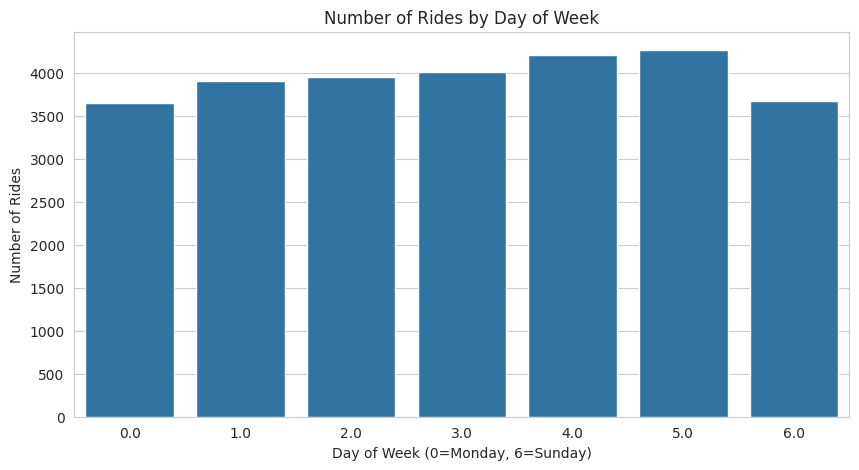

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['weekday'])
plt.title('Number of Rides by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Number of Rides')
plt.show()

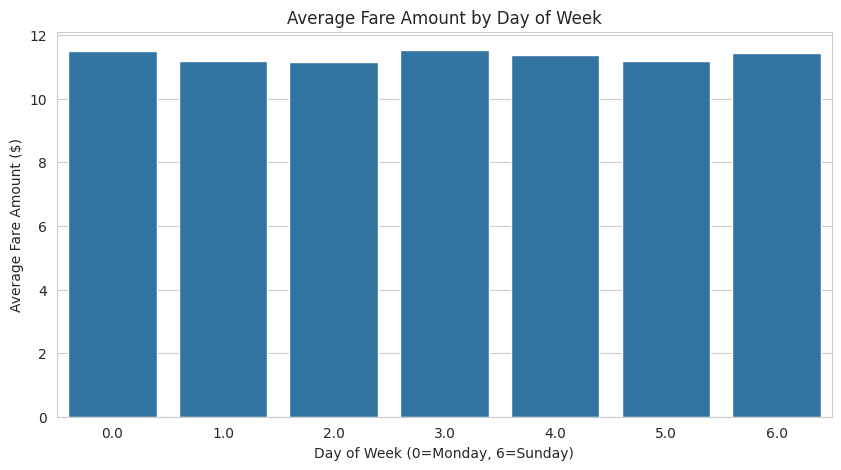

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=df['weekday'], y=df['fare_amount'], estimator='mean', errorbar=None)
plt.title('Average Fare Amount by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Fare Amount ($)')
plt.show()

Q12) When is demand highest , combining hour and day of week?

hour × weekday: both Numerical/Ordered

Ride Count: Frequency

Suitable plot: Pivot Heatmap

Why: Reveals two-variable patterns (e.g., "Friday evenings" or "weekday mornings") that a single count plot (Q9 or Q11 alone) can't show a classic "rush hour" style insight.

Interpretation: Demand piles up in the evenings on nearly every day, especially around commute hours and weekend nights a clearer "when is demand highest" picture than hour or day alone.

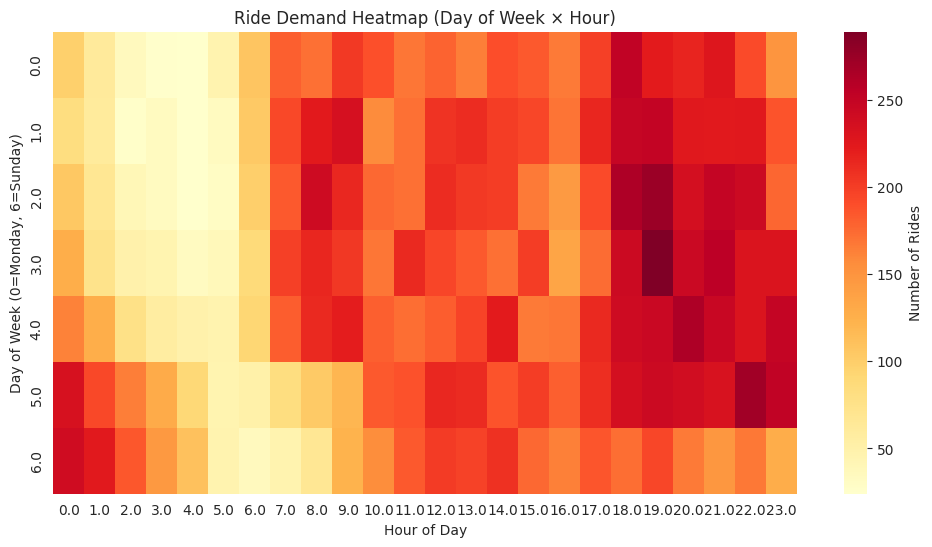

In [ ]:
plt.figure(figsize=(12, 6))
pivot = df.pivot_table(index='weekday', columns='hour', values='fare_amount', aggfunc='count')

sns.heatmap(pivot, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Number of Rides'})
plt.title('Ride Demand Heatmap (Day of Week × Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0=Monday, 6=Sunday)')
plt.show()

Q13) Where are pickups geographically concentrated in NYC?

pickup_latitude, pickup_longitude: Numerical (coordinates)

Suitable plot: Geo Scatter

Why: Shows the spatial distribution of pickup points, revealing hotspots of demand across the city . needs valid coordinates to be meaningful.

In [ ]:
df[['pickup_latitude', 'pickup_longitude']].describe()

,pickup_latitude,pickup_longitude
count,27646.000000,27646.000000
mean,0.697019,-1.265602
std,0.112786,0.181527
min,-1.291664,-1.316235
25%,0.710959,-1.291406
50%,0.711272,-1.291225
75%,0.711525,-1.290969
max,7.000225,0.711806


In [ ]:
#convert radians to degrees for plotting
df['pickup_latitude_deg'] = np.degrees(df['pickup_latitude'])
df['pickup_longitude_deg'] = np.degrees(df['pickup_longitude'])

df[['pickup_latitude_deg', 'pickup_longitude_deg']].describe()

,pickup_latitude_deg,pickup_longitude_deg
count,27646.000000,27646.000000
mean,39.936249,-72.513669
std,6.462173,10.400759
min,-74.006893,-75.414728
25%,40.734953,-73.992116
50%,40.752865,-73.981730
75%,40.767382,-73.967071
max,401.083332,40.783472


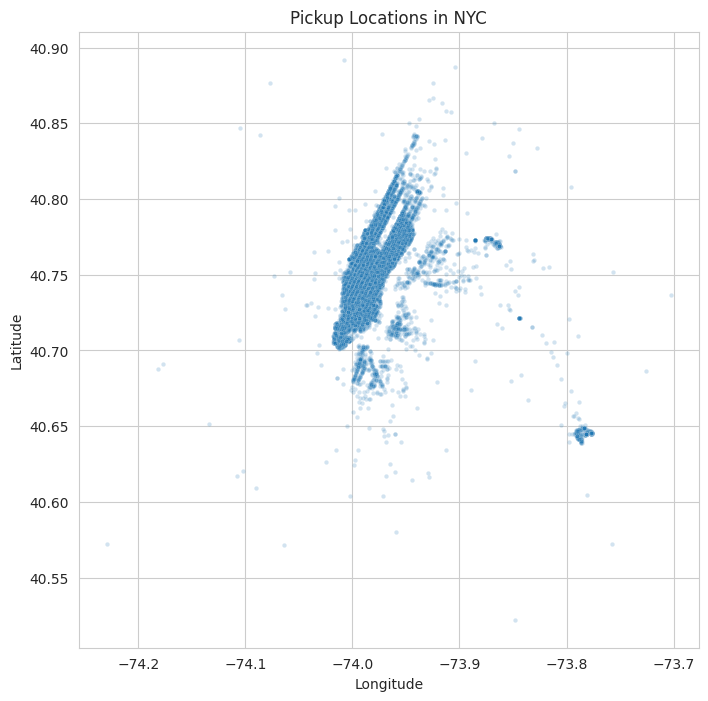

In [ ]:
plt.figure(figsize=(8, 8))
nyc_subset = df[
    (df['pickup_latitude_deg'].between(40.5, 40.9)) &
    (df['pickup_longitude_deg'].between(-74.3, -73.7))
]

sns.scatterplot(x=nyc_subset['pickup_longitude_deg'], y=nyc_subset['pickup_latitude_deg'], alpha=0.2, s=10)
plt.title('Pickup Locations in NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Q14) Which features correlate most strongly with fare overall?

All numeric features vs fare_amount

Suitable plot: Correlation Heatmap

Why: Summarizes linear relationships across all numeric features at once, helping identify which variables are most likely to matter in Task 2 (modeling). This revisits Q3's heatmap but frames it as a wrap-up: which features are strongest candidates for the model?

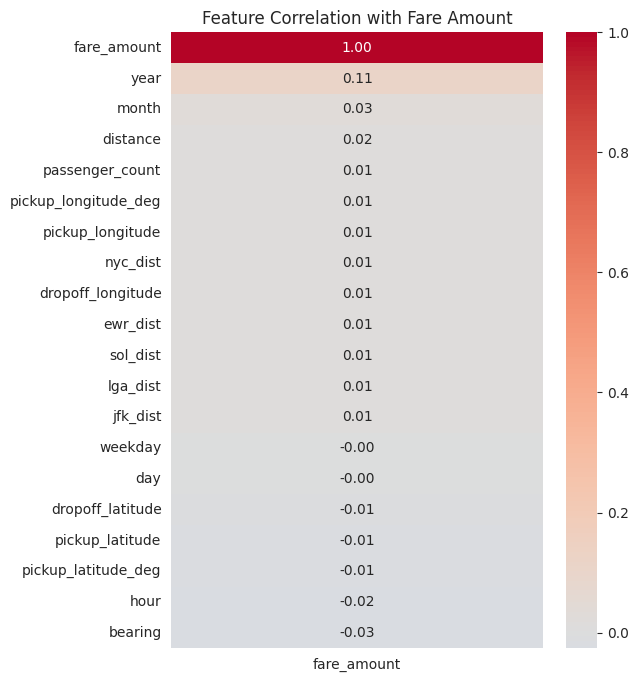

In [ ]:
plt.figure(figsize=(6, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()[['fare_amount']].sort_values(by='fare_amount', ascending=False)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation with Fare Amount')
plt.show()

Q15) Quick multi-feature overview: how do Fare, Distance, Passenger Count, and Hour relate to each other?

fare_amount, distance, passenger_count,
hour: all Numerical

Suitable plot: Pair Plot

Why: Gives a fast overview of all pairwise relationships between key features at once ,ties together insights from earlier questions (Q1-Q10) into a single summary visual.

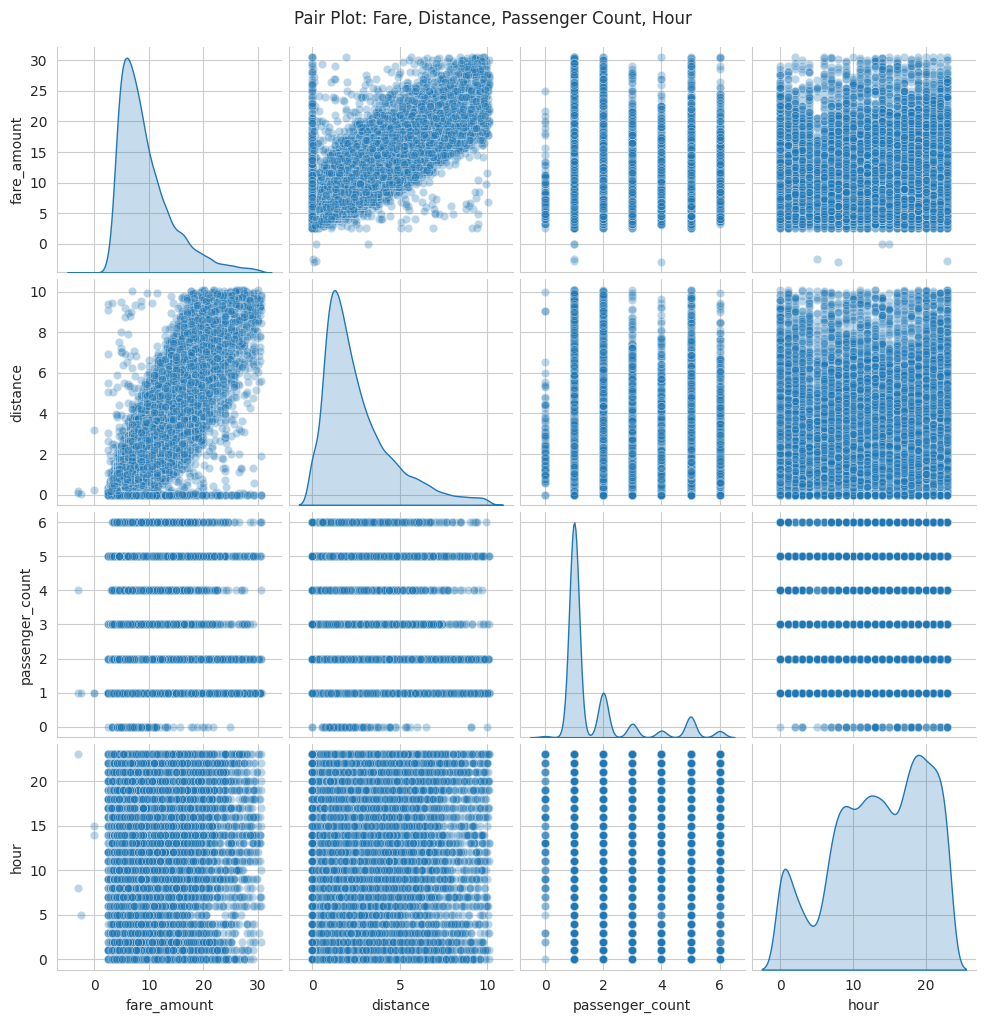

In [ ]:
fare_cap = df['fare_amount'].quantile(0.95)
dist_cap = df['distance'].quantile(0.95)

pairplot_subset = df[(df['fare_amount'] <= fare_cap) & (df['distance'] <= dist_cap)][
    ['fare_amount', 'distance', 'passenger_count', 'hour']
]

sns.pairplot(pairplot_subset, diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Pair Plot: Fare, Distance, Passenger Count, Hour', y=1.02)
plt.show()

## Summary: Data Cleaning Needed Before Task 2

- **`distance`**  has impossible outliers (max ~8,667 km vs median ~2 km). Cap or remove extreme values.
- **`jfk_dist`, `ewr_dist`, `lga_dist`**  same issue, worse (max ~30,000 km vs real range ~1–44 km). Needs same treatment.
- **Lat/long columns** stored in **radians**, not degrees. Must convert with `np.degrees()` before any geo feature engineering.
- **`fare_amount`** left-skewed with a real outlier tail . Consider log-transform instead of dropping.
- **`Car Condition`, `Traffic Condition`**  little effect on fare. Low priority for feature selection.
- **`passenger_count`**  minimal effect on fare. Low priority for feature selection.
- **`hour`, `weekday`, `month`** clean, no action needed. Good candidates for feature engineering (e.g. rush-hour flag).